The **Lecture slides** can be found [here](https://github.com/GDSL-UL/wma/blob/main/lectures/w01_intro.pdf).

This **lab**'s notebook can be downloaded from [here](https://github.com/GDSL-UL/wma/blob/main/labs/w01_intro.ipynb).

## Part I: Powerful (Web) Mapping Examples

This part of the lab has two main components:
1.  The first one will require you to find a partner and work together with them
2.  And the second one will involve group discussion.

### Paired Activity

In pairs, find **three** examples where web maps are used to communicate an idea. Complete the following sheet for each example:

-   **Substantive**
    -   `Title`: Title of the map/project
    -   `Author`: Who is behind the project?
    -   `Big idea`: a "one-liner" on what the project tries to accomplish --
    -   `Message`: what does the map try to get accross

-   **Technical**
    -   `URL`:
    -   `Interactivity`: does the map let you interact with it in any way? Yes/No
    -   `Zoomable`: can you explore the map at different scales? Yes/No
    -   `Design`: what geovisualisation solutions have been adopted?
    -   `Basemap`: Is there an underlying map providing geographical context? Yes/No. If so, who is it provided by?
    -   `Technology`: can you guess what technology does this map rely on?

Post each sheet as a separate item on the Teams channel for Lab No.1

#### Example
The project "WHO Coronavirus (COVID-19) Dashboard"

<img src="../labs_img/who_covid.png" width = 70%/>

-   **Substantive**

    -   `Title`: WHO Coronavirus (COVID-19) Dashboard
    -   `Author`: World Health Organization
    -   `Big idea`: Shows confirmed COVID-19 cases and deaths by country to date
    -   `Message`: The project displays a map of the world where COVID-19 cases are shown by country. This element is used to show which countries have had more cases (large trends). A drop down button allows us to visualise the map by a) Total per 100,000 population b) % change in the last 7 days c) newly reported in the last 7 days d) newly reported in the last 24 hours.

-   **Technical**
  
    -   `URL`: [`https://covid19.who.int/`](https://covid19.who.int/)
    -   `Interactivity`: Yes
    -   `Zoomable`: Yes
    -   `Tooltips`: Yes
    -   `Basemap`: No
    -   `Technology`: Unknown

### Class discussion

We will select a few examples posted and collectively discuss (some of) the following questions:

1.  What makes them powerful, what "speaks" to us?
2.  What could be improved, what is counter-intuitive?
3.  What design elements do they rely on?
4.  What technology do they use?

### References

-   For an excellent coverage of "visualisation literacy", Chapter 11 of Andy Kirk's ["Data Visualisation"](https://www.visualisingdata.com/book/) is a great start.
-   A comprehensive overview of computational notebooks and how they relate to modern scientific work is available on [Ch.1 of the GDS book](https://geographicdata.science/book/notebooks/01_geo_thinking.html).
-   A recent overview of notebooks in Geography is available in [Boeing & Arribas-Bel (2021)](https://gistbok.ucgis.org/bok-topics/gis-and-computational-notebooks)

## Part II: Python/Pandas (Refresher)

*Gabriele Filomena has prepared this notebook by readapting material shared on this [repository](https://github.com/gboeing/ppd599/tree/main).
Copyright (c) 2013-2023 Geoff Boeing.*

### Python

A quick overview of ubiquitous programming concepts including data types, for loops, if-then-else conditionals, and functions.

In [1]:
import numpy as np
import pandas as pd

In [2]:
# integers (int)
x = 100
type(x)

int

In [3]:
# floating-point numbers (float)
x = 100.5
type(x)

float

In [4]:
# sequence of characters (str)
x = 'Los Angeles, CA 90089'
len(x)

21

In [5]:
# list of items
x = [1, 2, 3, 'USC']
len(x)

4

In [6]:
# sets are unique
x = {2, 2, 3, 3, 1}
x

{1, 2, 3}

In [7]:
# tuples are immutable sequences
latlng = (34.019425, -118.283413)
type(latlng)

tuple

In [8]:
# you can unpack a tuple
lat, lng = latlng
type(lat)

float

In [9]:
# dictionary of key:value pairs
iceland = {'Country': 'Iceland', 'Population': 372520, 'Capital': 'Reykjavík', '% Foreign Population' : 0.18 }
type(iceland)

dict

In [10]:
# you can convert types
x = '100'
print(type(x))
y = int(x)
print(type(y))

<class 'str'>
<class 'int'>


In [11]:
# you can loop through an iterable, such as a list or tuple
for coord in latlng:
    print('Current coordinate is:', coord)

Current coordinate is: 34.019425
Current coordinate is: -118.283413


In [12]:
# loop through a dictionary keys and values as tuples
for key, value in iceland.items():
    print(key, value)

Country Iceland
Population 372520
Capital Reykjavík
% Foreign Population 0.18


In [13]:
# booleans are trues/falses
x = 101
x > 100

True

In [14]:
# use two == for equality and one = for assignment
x == 100

False

In [15]:
# if, elif, else for conditional branching execution
x = 101
if x > 100:
    print('Value is greater than 100.')
elif x < 100:
    print('Value is less than 100.')
else:
    print('Value is 100.')

Value is greater than 100.


In [16]:
# use functions to encapsulate and reuse bits of code
def convert_items(my_list, new_type=str):
    # convert each item in a list to a new type
    new_list = [new_type(item) for item in my_list]
    return new_list

l = [1, 2, 3, 4]
convert_items(l)

['1', '2', '3', '4']

### `pandas` Series and DataFrames

[pandas](https://pandas.pydata.org/) has two primary data structures we will work with: `Series` and `DataFrame`.

#### Pandas Series

In [17]:
# a pandas series is based on a numpy array: it's fast, compact, and has more functionality
# it has an index which allows you to work naturally with tabular data
my_list = [8, 5, 77, 2]
my_series = pd.Series(my_list)
my_series

0     8
1     5
2    77
3     2
dtype: int64

In [18]:
# look at a list-representation of the index
my_series.index.tolist()

[0, 1, 2, 3]

In [19]:
# look at the series' values themselves
my_series.values

array([ 8,  5, 77,  2])

In [20]:
# what's the data type of the series' values?
type(my_series.values)

numpy.ndarray

In [21]:
# what's the data type of the individual values themselves?
my_series.dtype

dtype('int64')

#### Pandas DataFrames

In [22]:
# a dict can contain multiple lists and label them
my_dict = {'hh_income'  : [75125, 22075, 31950, 115400],
           'home_value' : [525000, 275000, 395000, 985000]}
my_dict

{'hh_income': [75125, 22075, 31950, 115400],
 'home_value': [525000, 275000, 395000, 985000]}

In [23]:
# a pandas dataframe can contain one or more columns
# each column is a pandas series
# each row is a pandas series
# you can create a dataframe by passing in a list, array, series, or dict
df = pd.DataFrame(my_dict)
df

,hh_income,home_value
0,75125,525000
1,22075,275000
2,31950,395000
3,115400,985000


In [24]:
# the row labels in the index are accessed by the .index attribute of the DataFrame object
df.index.tolist()

[0, 1, 2, 3]

In [25]:
# the column labels are accessed by the .columns attribute of the DataFrame object
df.columns

Index(['hh_income', 'home_value'], dtype='str')

In [26]:
# the data values are accessed by the .values attribute of the DataFrame object
# this is a numpy (two-dimensional) array
df.values

array([[ 75125, 525000],
       [ 22075, 275000],
       [ 31950, 395000],
       [115400, 985000]])

### Loading data in Pandas

Usually, you'll work with data by loading a dataset file into pandas. CSV is the most common format. But pandas can also ingest tab-separated data, JSON, and proprietary file formats like Excel .xlsx files, Stata, SAS, and SPSS.

Below, notice what pandas's `read_csv` function does:

1. Recognize the header row and get its variable names.
1. Read all the rows and construct a pandas DataFrame (an assembly of pandas Series rows and columns).
1. Construct a unique index, beginning with zero.
1. Infer the data type of each variable (i.e., column).

In [27]:
# load a data file
# note the relative filepath! where is this file located?
# use dtype argument if you don't want pandas to guess your data types
df = pd.read_csv('../data/GTD_2022.csv', low_memory = False)

In [29]:
to_replace = [-9, -99, "-9", "-99"]
for value in to_replace:
    df = df.replace(value, np.nan)

df['eventid'] = df['eventid'].astype("Int64")

In [30]:
# dataframe shape as rows, columns
df.shape

(209706, 75)

In [31]:
# or use len to just see the number of rows
len(df)

209706

In [32]:
# view the dataframe's "head"
df.head()

,eventid,year,date,extended,country,country_txt,region,region_txt,city,latitude,...,kidhijcountry,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,201000000000,2005,28/05/2005,1,153,Pakistan,6,South Asia,Karachi,24.891115,...,Unknown,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,NaN,NaN,0.0,NaN,NaN
1,201000000000,2005,29/05/2005,1,95,Iraq,10,Middle East & North Africa,Kirkuk,35.452110,...,Unknown,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN
2,201000000000,2007,08/06/2007,1,95,Iraq,10,Middle East & North Africa,Kan'an,33.693409,...,NaN,0.0,6.0,Combination,0.0,0.0,0.0,0.0,0.0,NaN
3,201000000000,2010,15/06/2010,1,4,Afghanistan,6,South Asia,Saydabad,34.008430,...,NaN,NaN,4.0,Hostage(s) killed (not during rescue attempt),NaN,0.0,0.0,0.0,0.0,NaN
4,201000000000,2011,06/01/2011,1,92,India,6,South Asia,Midnapore,22.424109,...,NaN,NaN,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN


In [33]:
# view the dataframe's "tail"
df.tail()

,eventid,year,date,extended,country,country_txt,region,region_txt,city,latitude,...,kidhijcountry,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
209701,202000000000,2020,31/12/2020,0,228,Yemen,10,Middle East & North Africa,Sabaa,15.305307,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN
209702,202000000000,2020,31/12/2020,0,228,Yemen,10,Middle East & North Africa,Beit Maghari,13.931337,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN
209703,202000000000,2020,31/12/2020,0,75,Germany,8,Western Europe,Leipzig,51.342239,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
209704,202000000000,2020,31/12/2020,0,4,Afghanistan,6,South Asia,Kabul,34.523842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
209705,202000000000,2020,31/12/2020,1,33,Burkina Faso,11,Sub-Saharan Africa,Kelbo,13.864252,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [34]:
# column data types
df.dtypes

eventid       Int64
year          int64
date            str
extended      int64
country       int64
             ...   
INT_LOG     float64
INT_IDEO    float64
INT_MISC    float64
INT_ANY     float64
related         str
Length: 75, dtype: object

In [35]:
# or
for dt in df.columns[:10]:
    print(dt, type(dt))

eventid <class 'str'>
year <class 'str'>
date <class 'str'>
extended <class 'str'>
country <class 'str'>
country_txt <class 'str'>
region <class 'str'>
region_txt <class 'str'>
city <class 'str'>
latitude <class 'str'>


### Selecting and slicing data from a DataFrame

In [36]:
# CHEAT SHEET OF COMMON TASKS
# Operation                       Syntax           Result
#------------------------------------------------------------
# Select column by name           df[col]          Series
# Select columns by name          df[col_list]     DataFrame
# Select row by label             df.loc[label]    Series
# Select row by integer location  df.iloc[loc]     Series
# Slice rows by label             df.loc[a:c]      DataFrame
# Select rows by boolean vector   df[mask]         DataFrame

#### Select DataFrame's column(s) by name

In [37]:
# select a single column by column name
# this is a pandas series
df['country']

0         153
1          95
2          95
3           4
4          92
         ... 
209701    228
209702    228
209703     75
209704      4
209705     33
Name: country, Length: 209706, dtype: int64

In [38]:
# select multiple columns by a list of column names
# this is a pandas dataframe that is a subset of the original
df[['country_txt', 'year']]

,country_txt,year
0,Pakistan,2005
1,Iraq,2005
2,Iraq,2007
3,Afghanistan,2010
4,India,2011
...,...,...
209701,Yemen,2020
209702,Yemen,2020
209703,Germany,2020
209704,Afghanistan,2020


In [39]:
# create a new column by assigning df['new_col'] to some values
# people killed every perpetrator 
df['killed_per_attacker'] = df['nkill'] / df['nperps']

# inspect the results
df[['country', 'year', 'nkill', 'nperps', 'killed_per_attacker']].head(15)

,country,year,nkill,nperps,killed_per_attacker
0,153,2005,1.0,NaN,NaN
1,95,2005,1.0,NaN,NaN
2,95,2007,15.0,50.0,0.300000
3,4,2010,1.0,NaN,NaN
4,92,2011,1.0,NaN,NaN
5,160,2011,1.0,30.0,0.033333
6,95,2011,1.0,NaN,NaN
7,155,2002,7.0,3.0,2.333333
8,92,2010,5.0,100.0,0.050000
9,153,2011,4.0,NaN,NaN


#### Select row(s) by label

In [40]:
# use .loc to select by row label
# returns the row as a series whose index is the dataframe column names
df.loc[0]

eventid                201000000000
year                           2005
date                     28/05/2005
extended                          1
country                         153
                           ...     
INT_IDEO                        NaN
INT_MISC                        0.0
INT_ANY                         NaN
related                         NaN
killed_per_attacker             NaN
Name: 0, Length: 76, dtype: object

In [41]:
# use .loc to select single value by row label, column name
df.loc[15, 'gname'] #group name

'Taliban'

In [42]:
# slice of rows from label 5 to label 7, inclusive
# this returns a pandas dataframe
df.loc[5:7]

,eventid,year,date,extended,country,country_txt,region,region_txt,city,latitude,...,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,killed_per_attacker
5,201000000000,2011,08/01/2011,0,160,Philippines,5,Southeast Asia,Datu Danwata,6.287156,...,0.0,2.0,Hostage(s) released by perpetrators,1.0,0.0,0.0,0.0,0.0,NaN,0.033333
6,201000000000,2011,11/04/2011,1,95,Iraq,10,Middle East & North Africa,Hawijah,35.326122,...,NaN,4.0,Hostage(s) killed (not during rescue attempt),0.0,NaN,NaN,0.0,NaN,NaN,NaN
7,200000000000,2002,16/07/2002,0,155,West Bank and Gaza Strip,10,Middle East & North Africa,Emanuel,32.161864,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,2.333333


In [43]:
# slice of rows from label 17 to label 27, inclusive
# slice of columns from country_txt to city, inclusive
df.loc[17:27, 'country_txt':'city']

,country_txt,region,region_txt,city
17,India,6,South Asia,Mumbai
18,India,6,South Asia,Mumbai
19,Afghanistan,6,South Asia,Khost
20,India,6,South Asia,Unknown
21,Pakistan,6,South Asia,Lahore
22,Pakistan,6,South Asia,Lahore
23,Pakistan,6,South Asia,Mullazai
24,Colombia,3,South America,El Tambo
25,Nigeria,11,Sub-Saharan Africa,Unknown
26,Pakistan,6,South Asia,Quetta


In [44]:
# subset of rows from with labels in list
# subset of columns with names in list
df.loc[[1, 350], ['country', 'gname']]

,country,gname
1,95,Ansar al-Sunna
350,147,Boko Haram


In [45]:
# you can use a column of identifiers as the index (indices do not *need* to be unique)
df_gname = df.set_index('gname')
df_gname.index.is_unique

False

In [46]:
df_gname.head(3)

,eventid,year,date,extended,country,country_txt,region,region_txt,city,latitude,...,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,killed_per_attacker
gname,,,,,,,,,,,,,,,,,,,,,
Unknown,201000000000,2005,28/05/2005,1,153,Pakistan,6,South Asia,Karachi,24.891115,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,NaN,NaN,0.0,NaN,NaN,NaN
Ansar al-Sunna,201000000000,2005,29/05/2005,1,95,Iraq,10,Middle East & North Africa,Kirkuk,35.452110,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN,NaN
Al-Qaida in Iraq,201000000000,2007,08/06/2007,1,95,Iraq,10,Middle East & North Africa,Kan'an,33.693409,...,0.0,6.0,Combination,0.0,0.0,0.0,0.0,0.0,NaN,0.3


In [47]:
# .loc works by label, not by position in the dataframe
try:
    df_gname.loc[0]
except KeyError as e:
    print('label not found')

label not found


In [48]:
# the index now contains gname values, so you have to use .loc accordingly to select by row label
df_gname.loc['Taliban'].head()

,eventid,year,date,extended,country,country_txt,region,region_txt,city,latitude,...,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,killed_per_attacker
gname,,,,,,,,,,,,,,,,,,,,,
Taliban,201000000000,2010,15/06/2010,1,4,Afghanistan,6,South Asia,Saydabad,34.008430,...,NaN,4.0,Hostage(s) killed (not during rescue attempt),NaN,0.0,0.0,0.0,0.0,NaN,NaN
Taliban,201000000000,2006,26/08/2006,0,4,Afghanistan,6,South Asia,Muqur district,32.816136,...,NaN,7.0,Unknown,NaN,0.0,0.0,0.0,0.0,NaN,NaN
Taliban,201000000000,2008,27/04/2008,0,4,Afghanistan,6,South Asia,Muhmand Dara district,34.255278,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
Taliban,201000000000,2009,12/05/2009,0,4,Afghanistan,6,South Asia,Khost,33.335258,...,0.0,5.0,Successful Rescue,20.0,0.0,0.0,0.0,0.0,"200905120009, 200905120021, 200905120022",0.3
Taliban,201000000000,2014,28/03/2014,0,4,Afghanistan,6,South Asia,Kabul,34.516895,...,0.0,5.0,Successful Rescue,5.0,0.0,1.0,1.0,1.0,NaN,1.2


#### Select by (integer) position - Independent from actual Index

In [49]:
# get the row in the zero-th position in the dataframe
df.iloc[0]

eventid                201000000000
year                           2005
date                     28/05/2005
extended                          1
country                         153
                           ...     
INT_IDEO                        NaN
INT_MISC                        0.0
INT_ANY                         NaN
related                         NaN
killed_per_attacker             NaN
Name: 0, Length: 76, dtype: object

In [50]:
# you can slice as well
# note, while .loc is inclusive, .iloc is not
# get the rows from position 0 up to but not including position 3 (ie, rows 0, 1, and 2)
df.iloc[0:3]

,eventid,year,date,extended,country,country_txt,region,region_txt,city,latitude,...,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,killed_per_attacker
0,201000000000,2005,28/05/2005,1,153,Pakistan,6,South Asia,Karachi,24.891115,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,NaN,NaN,0.0,NaN,NaN,NaN
1,201000000000,2005,29/05/2005,1,95,Iraq,10,Middle East & North Africa,Kirkuk,35.452110,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,201000000000,2007,08/06/2007,1,95,Iraq,10,Middle East & North Africa,Kan'an,33.693409,...,0.0,6.0,Combination,0.0,0.0,0.0,0.0,0.0,NaN,0.3


In [51]:
# get the value from the row in position 3 and the column in position 2 (zero-indexed)
df.iloc[3, 6] #country_txt

np.int64(6)

#### Select/filter by value

You can subset or filter a dataframe for based on the values in its rows/columns.

In [52]:
# filter the dataframe by urban areas with more than 25 million residents
df[df['nkill'] > 30].head()

,eventid,year,date,extended,country,country_txt,region,region_txt,city,latitude,...,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,killed_per_attacker
17,201000000000,2008,26/11/2008,1,92,India,6,South Asia,Mumbai,19.075984,...,0.0,6.0,Combination,NaN,0.0,1.0,0.0,1.0,"200811130010, 200811260001, 200811260002, 2008...",17.00
18,201000000000,2008,26/11/2008,1,92,India,6,South Asia,Mumbai,19.075984,...,0.0,6.0,Combination,NaN,0.0,1.0,0.0,1.0,"200811130010, 200811260001, 200811260002, 2008...",16.00
27,201000000000,2013,21/09/2013,1,104,Kenya,11,Sub-Saharan Africa,Nairobi,-1.285180,...,0.0,6.0,Combination,NaN,1.0,1.0,0.0,1.0,NaN,NaN
38,201000000000,2014,17/07/2014,1,200,Syria,10,Middle East & North Africa,Palmyra district,34.608148,...,0.0,6.0,Combination,NaN,0.0,1.0,0.0,1.0,NaN,NaN
39,201000000000,2014,24/07/2014,0,200,Syria,10,Middle East & North Africa,Raqqah,35.951521,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,1.0,0.0,1.0,NaN,0.19


In [53]:
# you can chain multiple conditions together
# pandas logical operators are: | for or, & for and, ~ for not
# these must be grouped by using parentheses due to order of operations
df[['country','nkill', 'nwound']][(df['nkill'] > 200) & (df['nwound'] > 10)].head()
# columns on the left-hand side are here used to slice the resulting output

,country,nkill,nwound
427,229,339.0,28.0
1000,217,1385.0,10878.0
1001,217,1385.0,10878.0
2780,1004,287.0,400.0
3787,4,266.0,64.0


In [54]:
# ~ means not... it essentially flips trues to falses and vice-versa
df[['country','nkill', 'nwound']][~(df['nkill'] > 200) & (df['nwound'] > 10)]

,country,nkill,nwound
7,155,7.0,16.0
17,92,68.0,76.0
18,92,32.0,22.0
19,4,9.0,25.0
21,153,29.0,31.0
...,...,...,...
209528,4,10.0,15.0
209547,153,3.0,17.0
209636,4,1.0,13.0
209659,153,0.0,14.0


### Grouping and summarizing

In [55]:
# group by terroristic group name
groups = df.groupby('gname')

In [56]:
# what is the median number of people killed per event across the different groups?
groups['nkill'].median().sort_values(ascending=False)

gname
Samri militia                                        766.0
Gumuz militia                                        222.0
Dissident Military Mmbrs of Northern Tribal Group    150.0
Ansar al-Din Front                                   103.0
Issa and Gurgura Liberation Front                    100.0
                                                     ...  
Western Somalia Liberation Front                       NaN
Workers of the Company                                 NaN
World Punishment Organization                          NaN
Zawiya Martyrs Brigade                                 NaN
Zimbabwe Guerrillas                                    NaN
Name: nkill, Length: 3725, dtype: float64

In [57]:
# look at several columns' medians by group
groups[['nkill', 'nwound', 'nperps']].median()

,nkill,nwound,nperps
gname,,,
01-May,0.0,0.0,1.5
09-Feb,0.0,0.0,NaN
14 K Triad,0.0,0.0,8.0
14 March Coalition,5.0,80.0,NaN
14th of December Command,0.0,0.0,NaN
...,...,...,...
Zulu Miners,1.0,10.0,NaN
Zuwar al-Imam Rida,0.0,0.0,4.0
Zviadists,0.0,0.0,NaN


In [58]:
# you can create a new dataFrame by directly passing columns between "[[ ]]", after the groupby function
# to do so, you also need to pass a function that can deal with the values (e.g. sum..etc) 
western_europe = df[df.region_txt == 'Western Europe']
western_europe.groupby('country_txt')[['nkill', 'nwound']].sum().sort_values('nkill', ascending = False).reset_index()

,country_txt,nkill,nwound
0,United Kingdom,3426.0,6321.0
1,Spain,1289.0,4937.0
2,France,565.0,2565.0
3,Italy,420.0,1320.0
4,Greece,264.0,763.0
5,Ireland,108.0,26.0
6,Germany,103.0,735.0
7,West Germany (FRG),97.0,862.0
8,Belgium,83.0,523.0
9,Norway,80.0,90.0


### Indexes

Each `DataFrame` has an index. Indexes do not have to be unique (but that would be for the best)

In [59]:
# resetting index (when loading a .csv file pandas creates an index automatically, from 0 to Nrecords-1)
df.reset_index(drop = True).sort_index().head() # this does not assign the new index though, it just shows you a temp copy

,eventid,year,date,extended,country,country_txt,region,region_txt,city,latitude,...,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,killed_per_attacker
0,201000000000,2005,28/05/2005,1,153,Pakistan,6,South Asia,Karachi,24.891115,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,NaN,NaN,0.0,NaN,NaN,NaN
1,201000000000,2005,29/05/2005,1,95,Iraq,10,Middle East & North Africa,Kirkuk,35.452110,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,201000000000,2007,08/06/2007,1,95,Iraq,10,Middle East & North Africa,Kan'an,33.693409,...,0.0,6.0,Combination,0.0,0.0,0.0,0.0,0.0,NaN,0.3
3,201000000000,2010,15/06/2010,1,4,Afghanistan,6,South Asia,Saydabad,34.008430,...,NaN,4.0,Hostage(s) killed (not during rescue attempt),NaN,0.0,0.0,0.0,0.0,NaN,NaN
4,201000000000,2011,06/01/2011,1,92,India,6,South Asia,Midnapore,22.424109,...,NaN,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [60]:
#this does assign the new index to your df
df = df.reset_index(drop = True).sort_index() 
df.head()

,eventid,year,date,extended,country,country_txt,region,region_txt,city,latitude,...,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,killed_per_attacker
0,201000000000,2005,28/05/2005,1,153,Pakistan,6,South Asia,Karachi,24.891115,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,NaN,NaN,0.0,NaN,NaN,NaN
1,201000000000,2005,29/05/2005,1,95,Iraq,10,Middle East & North Africa,Kirkuk,35.452110,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,201000000000,2007,08/06/2007,1,95,Iraq,10,Middle East & North Africa,Kan'an,33.693409,...,0.0,6.0,Combination,0.0,0.0,0.0,0.0,0.0,NaN,0.3
3,201000000000,2010,15/06/2010,1,4,Afghanistan,6,South Asia,Saydabad,34.008430,...,NaN,4.0,Hostage(s) killed (not during rescue attempt),NaN,0.0,0.0,0.0,0.0,NaN,NaN
4,201000000000,2011,06/01/2011,1,92,India,6,South Asia,Midnapore,22.424109,...,NaN,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [61]:
# index isn't unique
df.index.is_unique

True

In [62]:
# you can set a new index
# drop -> Delete columns to be used as the new index.
# append ->  whether to append columns to existing index.
df = df.set_index('eventid', drop=True, append=False)
df.index.name = None # remove the index "name"
df.head()

# this index is not ideal, but it's the original source's id

,year,date,extended,country,country_txt,region,region_txt,city,latitude,longitude,...,ransom,hostkidoutcome,hostkidoutcome_txt,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,killed_per_attacker
201000000000,2005,28/05/2005,1,153,Pakistan,6,South Asia,Karachi,24.891115,67.143311,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,NaN,NaN,0.0,NaN,NaN,NaN
201000000000,2005,29/05/2005,1,95,Iraq,10,Middle East & North Africa,Kirkuk,35.452110,44.375465,...,0.0,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN,NaN
201000000000,2007,08/06/2007,1,95,Iraq,10,Middle East & North Africa,Kan'an,33.693409,44.796085,...,0.0,6.0,Combination,0.0,0.0,0.0,0.0,0.0,NaN,0.3
201000000000,2010,15/06/2010,1,4,Afghanistan,6,South Asia,Saydabad,34.008430,68.717888,...,NaN,4.0,Hostage(s) killed (not during rescue attempt),NaN,0.0,0.0,0.0,0.0,NaN,NaN
201000000000,2011,06/01/2011,1,92,India,6,South Asia,Midnapore,22.424109,87.318986,...,NaN,4.0,Hostage(s) killed (not during rescue attempt),0.0,0.0,0.0,0.0,0.0,NaN,NaN


## Part III: Geospatial Vector data in Python

*Gabriele Filomena has prepared this notebook by readapting material shared on this [repository](https://github.com/jorisvandenbossche/geopandas-tutorial).
Copyright (c) 2018, Joris Van den Bossche.*

In [63]:
%matplotlib inline

import geopandas as gpd

### Importing geospatial data

GeoPandas builds on Pandas types `Series` and `Dataframe`, by incorporating information about geographical space.

- `GeoSeries`: a Series object designed to store shapely geometry object
- `GeoDataFrame`: object is a pandas DataFrame that has a column with geometry (that contains a *Geoseries*)

We can use the GeoPandas library to read many of GIS file formats (relying on the `fiona` library under the hood, which is an interface to GDAL/OGR), using the `gpd.read_file` function. For example, let's start by reading a shapefile with all the countries of the world (adapted from http://www.naturalearthdata.com/downloads/110m-cultural-vectors/110m-admin-0-countries/, zip file is available in the `/data` directory), and inspect the data:

In [64]:
countries = gpd.read_file("../data/ne_countries.zip")
# or if the archive is unpacked:
# countries = gpd.read_file("../data/ne_countries.shp")

In [65]:
countries.head()

,iso_a3,name,continent,pop_est,gdp_md_est,geometry
0,AFG,Afghanistan,Asia,34124811.0,64080.0,"POLYGON ((61.21082 35.65007, 62.23065 35.27066..."
1,AGO,Angola,Africa,29310273.0,189000.0,"MULTIPOLYGON (((23.90415 -11.72228, 24.07991 -..."
2,ALB,Albania,Europe,3047987.0,33900.0,"POLYGON ((21.02004 40.84273, 20.99999 40.58, 2..."
3,ARE,United Arab Emirates,Asia,6072475.0,667200.0,"POLYGON ((51.57952 24.2455, 51.75744 24.29407,..."
4,ARG,Argentina,South America,44293293.0,879400.0,"MULTIPOLYGON (((-66.95992 -54.89681, -67.56244..."


<Axes: >

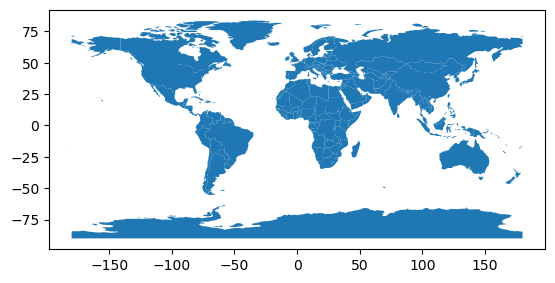

In [66]:
countries.plot()

We observe that:

- Using `.head()` we can see the first rows of the dataset, just like we can do with Pandas.
- There is a `geometry` column and the different countries are represented as polygons
- We can use the `.plot()` (matplotlib) method to quickly get a *basic* visualization of the data

### What's a GeoDataFrame?

We used the GeoPandas library to read in the geospatial data, and this returned us a `GeoDataFrame`:

In [67]:
type(countries)

geopandas.geodataframe.GeoDataFrame

A GeoDataFrame contains a tabular, geospatial dataset:

* It has a 'geometry' column that holds the geometry information (or features in GeoJSON).
* The other columns are the **attributes** (or properties in GeoJSON) that describe each of the geometries.

Such a `GeoDataFrame` is just like a pandas `DataFrame`, but with some additional functionality for working with geospatial data:
* A `geometry` attribute that always returns the column with the geometry information (returning a `GeoSeries`). The column name itself does not necessarily need to be 'geometry', but it will always be accessible as the `geometry` attribute.
* It has some extra methods for working with spatial data (area, distance, buffer, intersection, ...) [see here, for example](https://github.com/jorisvandenbossche/geopandas-tutorial/blob/main/04-spatial-operations-overlays.ipynb).

In [68]:
countries.geometry.head()

0    POLYGON ((61.21082 35.65007, 62.23065 35.27066...
1    MULTIPOLYGON (((23.90415 -11.72228, 24.07991 -...
2    POLYGON ((21.02004 40.84273, 20.99999 40.58, 2...
3    POLYGON ((51.57952 24.2455, 51.75744 24.29407,...
4    MULTIPOLYGON (((-66.95992 -54.89681, -67.56244...
Name: geometry, dtype: geometry

In [69]:
type(countries.geometry)

geopandas.geoseries.GeoSeries

In [70]:
countries.geometry.area

C:\Users\gfilo\AppData\Local\Temp\ipykernel_2500\3077649407.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  countries.geometry.area


0       63.593500
1      103.599439
2        3.185163
3        7.095047
4      278.923392
          ...    
172      0.631326
173     38.475618
174    112.718524
175     62.789498
176     32.280371
Length: 177, dtype: float64

It's still a `DataFrame`, so we have all the `pandas` functionality available to use on the geospatial dataset, and to do data manipulations with the attributes and geometry information together. For example, we can calculate the average population over all countries (by accessing the 'pop_est' column, and calling the `mean` method on it):

In [71]:
countries['pop_est'].mean()

np.float64(41712369.84180791)

In [72]:
africa = countries[countries['continent'] == 'Africa']

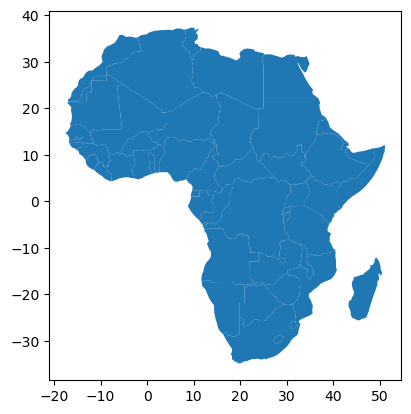

In [73]:
africa.plot();

The rest of the tutorial is going to assume you already know some pandas basics, but we will try to give hints for that part for those that are not familiar.

<div class="alert alert-info" style="font-size:120%">

**Important:** <br>

* A `GeoDataFrame` allows to perform typical tabular data analysis together with spatial operations
* A `GeoDataFrame` (or *Feature Collection*) consists of:
    * **Geometries** or **features**: the spatial objects
    * **Attributes** or **properties**: columns with information about each spatial object

</div>

### Geometries: Points, Linestrings and Polygons

Spatial **vector** data can consist of different types, and the 3 fundamental types are:

<img src="../labs_img/simple_features_3_text.svg" width="70%">

* **Point** data: represents a single point in space.
* **Line** data ("LineString"): represented as a sequence of points that form a line.
* **Polygon** data: represents a filled area.

And each of them can also be combined in multi-part geometries (See https://shapely.readthedocs.io/en/stable/manual.html#geometric-objects for extensive overview).

For the example we have seen up to now, the individual geometry objects are Polygons:

In [74]:
print(countries.geometry[2])

POLYGON ((21.0200403174764 40.84272695572588, 20.999989861747224 40.58000397395401, 20.674996779063633 40.43499990494303, 20.615000441172754 40.11000682225935, 20.15001590341052 39.62499766698397, 19.980000441170148 39.69499339452341, 19.960001661873207 39.91500580500605, 19.406081984136733 40.250773423822466, 19.319058872157143 40.72723012955356, 19.40354983895429 41.40956574153546, 19.540027296637106 41.71998607031276, 19.37176883309496 41.877547512370654, 19.37176816334725 41.877550679783496, 19.304486118250793 42.19574514420782, 19.73805138517963 42.68824738216557, 19.801613396898688 42.50009349219084, 20.070700000000045 42.58863000000008, 20.283754510181893 42.32025950781508, 20.522950000000037 42.21787000000006, 20.590246546680227 41.855408919283626, 20.59024743010491 41.855404161133606, 20.463175083099202 41.51508901627534, 20.605181919037364 41.086226304685226, 21.0200403174764 40.84272695572588))


Let's import some other datasets with different types of geometry objects.

A dateset about cities in the world (adapted from http://www.naturalearthdata.com/downloads/110m-cultural-vectors/110m-populated-places/, zip file is available in the `/data` directory), consisting of `Point` data:

In [75]:
cities = gpd.read_file("../data/ne_cities.zip")

In [76]:
print(cities.geometry[0])

POINT (12.453386544971766 41.903282179960115)


And a dataset of rivers in the world (from http://www.naturalearthdata.com/downloads/50m-physical-vectors/50m-rivers-lake-centerlines/, zip file is available in the `/data` directory) where each river is a `(Multi-)LineString`:

In [77]:
rivers = gpd.read_file("../data/ne_rivers.zip")

In [78]:
print(rivers.geometry[0])

LINESTRING (51.9371337598152 55.70106609892139, 51.880866467313695 55.68625891701544, 51.82031249962222 55.697455145538584, 51.747601827462404 55.69366250841807, 51.6628417966117 55.608172918745254, 51.57871093775964 55.59943268477065, 51.51342773400279 55.58312409100404, 51.508544921610905 55.52948639548083, 51.48583984403365 55.49640534033426, 51.36914062543957 55.46796295772435, 51.213062548697735 55.50264985760492, 51.13452148447897 55.48273346527725, 51.079345702742046 55.46759674659262, 50.98022460947817 55.46637604371949, 50.83445217522774 55.45630956063775, 50.6883789060617 55.42011139502489, 50.4118652342932 55.401190496444315, 50.07802734358711 55.381122137576654, 49.822167968676865 55.334662176818085, 49.53222656260584 55.260614325191, 49.38232421848795 55.17182037990665, 49.24808475131027 55.11301870345045)


### The `shapely` library

The individual geometry objects are provided by the [`shapely`](https://shapely.readthedocs.io/en/stable/) library

In [79]:
from shapely.geometry import Point, Polygon, LineString

In [80]:
type(countries.geometry[0])

shapely.geometry.polygon.Polygon

To construct one ourselves:

In [81]:
p = Point(0, 0)

In [82]:
print(p)

POINT (0 0)


In [83]:
polygon = Polygon([(1, 1), (2,2), (2, 1)])

In [84]:
polygon.area

0.5

In [85]:
polygon.distance(p)

1.4142135623730951

<div class="alert alert-info" style="font-size:120%">

**Important**: <br>

Single geometries are represented by `shapely` objects:

* If you access a single geometry of a GeoDataFrame, you get a shapely geometry object
* Those objects have similar functionality as geopandas objects (GeoDataFrame/GeoSeries). For example:
    * `single_shapely_object.distance(other_point)` -> distance between two points
    * `geodataframe.distance(other_point)` ->  distance for each point in the geodataframe to the other point

</div>

### Plotting

[(-20.0, 60.0), (-40.0, 40.0)]

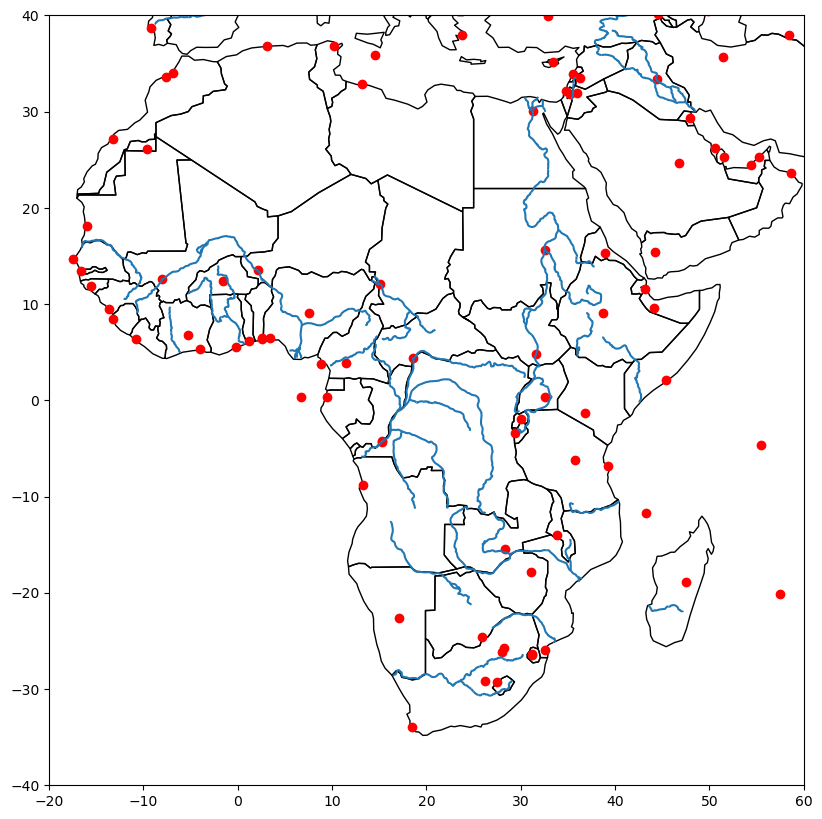

In [86]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(15, 10))
countries.plot(ax = ax, edgecolor='k', facecolor='none')
rivers.plot(ax=ax)
cities.plot(ax=ax, color='red')
ax.set(xlim=(-20, 60), ylim=(-40, 40))

### Creating GeoDataFrames (withouth specifying the CRS)

In [87]:
gpd.GeoDataFrame({
    'geometry': [Point(1, 1), Point(2, 2)],
    'attribute1': [1, 2],
    'attribute2': [0.1, 0.2]})

,geometry,attribute1,attribute2
0,POINT (1 1),1,0.1
1,POINT (2 2),2,0.2


In [88]:
# Creating a GeoDataFrame from an existing dataframe
# For example, if you have lat/lon coordinates in two columns:
df = pd.DataFrame(
    {'City': ['Buenos Aires', 'Brasilia', 'Santiago', 'Bogota', 'Caracas'],
     'Country': ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Venezuela'],
     'Latitude': [-34.58, -15.78, -33.45, 4.60, 10.48],
     'Longitude': [-58.66, -47.91, -70.66, -74.08, -66.86]})

In [89]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))
gdf

,City,Country,Latitude,Longitude,geometry
0,Buenos Aires,Argentina,-34.58,-58.66,POINT (-58.66 -34.58)
1,Brasilia,Brazil,-15.78,-47.91,POINT (-47.91 -15.78)
2,Santiago,Chile,-33.45,-70.66,POINT (-70.66 -33.45)
3,Bogota,Colombia,4.60,-74.08,POINT (-74.08 4.6)
4,Caracas,Venezuela,10.48,-66.86,POINT (-66.86 10.48)


# Practice

Throughout the exercises in this course, we will work with several datasets about the city of Paris.

Here, we start with the following datasets:

- The administrative districts of Paris (https://opendata.paris.fr/explore/dataset/quartier_paris/): `paris_districts_utm.geojson`
- Real-time (at the moment I downloaded them ..) information about the public bicycle sharing system in Paris (vélib, https://opendata.paris.fr/explore/dataset/stations-velib-disponibilites-en-temps-reel/information/): `data/paris_bike_stations_mercator.gpkg`

Both datasets are provided as spatial datasets using a GIS file format.

<div class="alert alert-success">

**Excercise 1**:

We will start by exploring the bicycle station dataset (available as a GeoPackage file: `data/paris_bike_stations_mercator.gpkg`)
    
* Read the stations datasets into a GeoDataFrame called `stations`.
* Check the type of the returned object
* Check the first rows of the dataframes. What kind of geometries does this datasets contain?
* How many features are there in the dataset? 
    
<details><summary>Hints</summary>

* Use `type(..)` to check any Python object type
* The `gpd.read_file()` function can read different geospatial file formats. You pass the file name as first argument.
* Use the `.shape` attribute to get the number of features

</details>
    
</div>

<div class="alert alert-success">

**Exercise 2**:

* Make a quick plot of the `stations` dataset.
* Make the plot a bit larger by setting the figure size to (12, 6) (hint: the `plot` method accepts a `figsize` keyword).
 
</div>

<div class="alert alert-success">

**Exercise 3**:

Next, we will explore the dataset on the administrative districts of Paris (available as a GeoJSON file: `../data/paris_districts_utm.geojson`)

* Read the dataset into a GeoDataFrame called `districts`.
* Check the first rows of the dataframe. What kind of geometries does this dataset contain?
* How many features are there in the dataset? (hint: use the `.shape` attribute)
* Make a quick plot of the `districts` dataset (set the figure size to (12, 6)).
    
</div>

<div class="alert alert-success">

**Exercise 4**:
    
What are the largest districts (biggest area)?

* Calculate the area of each district.
* Add this area as a new column to the `districts` dataframe.
* Sort the dataframe by the area column from largest to smallest values (descending).

<details><summary>Hints</summary>

* Adding a column can be done by assigning values to a column using the same square brackets syntax: `df['new_col'] = values`
* To sort the rows of a DataFrame, use the `sort_values()` method, specifying the colum to sort on with the `by='col_name'` keyword. Check the help of this method to see how to sort ascending or descending.

</details>

</div>

## Part IV: Coordinate reference systems & Projections

*Gabriele Filomena has prepared this notebook by readapting material shared on this [repository](https://github.com/jorisvandenbossche/geopandas-tutorial).
Copyright (c) 2018, Joris Van den Bossche.*

In [90]:
countries = gpd.read_file("../data/ne_countries.zip")
cities = gpd.read_file("../data/ne_cities.zip")
rivers = gpd.read_file("../data/ne_rivers.zip")

### Coordinate reference systems

Up to now, we have used the geometry data with certain coordinates without further wondering what those coordinates mean or how they are expressed.

> The **Coordinate Reference System (CRS)** relates the coordinates to a specific location on earth.

For an in-depth explanation, see https://docs.qgis.org/2.8/en/docs/gentle_gis_introduction/coordinate_reference_systems.html

#### Geographic coordinates

> Degrees of latitude and longitude.
>
> E.g. 48°51′N, 2°17′E

The most known type of coordinates are geographic coordinates: we define a position on the globe in degrees of latitude and longitude, relative to the equator and the prime meridian. 
With this system, we can easily specify any location on earth. It is used widely, for example in GPS. If you inspect the coordinates of a location in Google Maps, you will also see latitude and longitude.

**Attention!**

in Python we use (lon, lat) and not (lat, lon)

- Longitude: [-180, 180]{{1}}
- Latitude: [-90, 90]{{1}}

### Projected coordinates

> `(x, y)` coordinates are usually in meters or feet

Although the earth is a globe, in practice we usually represent it on a flat surface: think about a physical map, or the figures we have made with Python on our computer screen.
Going from the globe to a flat map is what we call a *projection*.

<img src="../labs_img/projection.png" width = 70%>

We project the surface of the earth onto a 2D plane so we can express locations in cartesian x and y coordinates, on a flat surface. In this plane, we then typically work with a length unit such as meters instead of degrees, which makes the analysis more convenient and effective.

However, there is an important remark: the 3 dimensional earth can never be represented perfectly on a 2 dimensional map, so projections inevitably introduce distortions. To minimize such errors, there are different approaches to project, each with specific advantages and disadvantages.

Some projection systems will try to preserve the area size of geometries, such as the Albers Equal Area projection. Other projection systems try to preserve angles, such as the Mercator projection, but will see big distortions in the area. Every projection system will always have some distortion of area, angle or distance.

<table><tr>
<td> <img src="../labs_img/projections-AlbersEqualArea.png"> </td>
<td> <img src="../labs_img/projections-Mercator.png"> </td>
</tr>
<tr>
<td> <img src="../labs_img/projections-Robinson.png"> </td>
</tr></table>

**Projected size vs actual size (Mercator projection)**:
<img src="../labs_img/mercator_projection_area.gif">

### Coordinate Reference Systems in Python / GeoPandas

A GeoDataFrame or GeoSeries has a `.crs` attribute which holds (optionally) a description of the coordinate reference system of the geometries:

In [91]:
countries.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

For the `countries` dataframe, it indicates that it uses the EPSG 4326 / WGS84 lon/lat reference system, which is one of the most used for geographic coordinates.


It uses coordinates as latitude and longitude in degrees, as can you be seen from the x/y labels on the plot:

<Axes: >

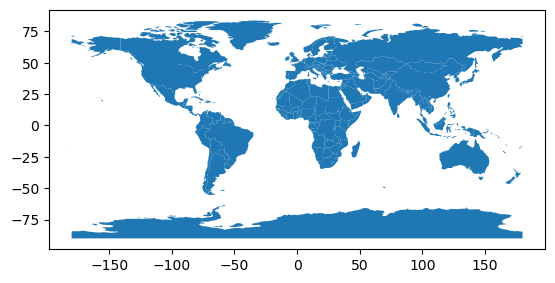

In [92]:
countries.plot()

The `.crs` attribute returns a `pyproj.CRS` object. To specify a CRS, we typically use some string representation:

- **EPSG code**
  Example: `EPSG:4326` = WGS84 geographic CRS (longitude, latitude)
  
For more information, see also http://geopandas.readthedocs.io/en/latest/projections.html.

#### Transforming to another CRS

We can convert a GeoDataFrame to another reference system using the `to_crs` function. 

For example, let's convert the countries to the World Mercator projection (http://epsg.io/3395):

<Axes: >

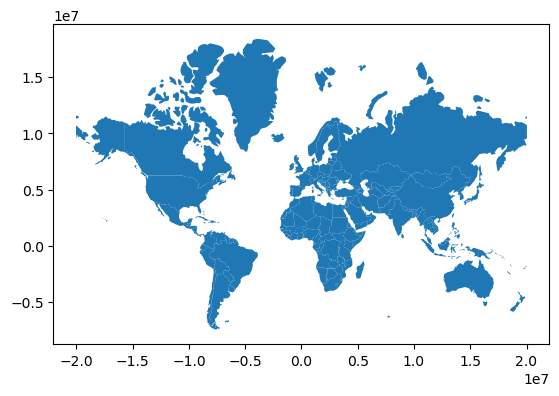

In [93]:
# remove Antartica, as the Mercator projection cannot deal with the poles
countries = countries[(countries['name'] != "Antarctica")]
countries_mercator = countries.to_crs(epsg=3395)  # or .to_crs("EPSG:3395")
countries_mercator.plot()

Note the different scale of x and y.

#### Why using a different CRS?

There are sometimes good reasons you want to change the coordinate references system of your dataset, for example:

- Different sources with different CRS -> need to convert to the same crs.   
- Different countries/geographical areas with different CRS.
- Mapping (distortion of shape and distances).
- Distance / area based calculations -> ensure you use an appropriate projected coordinate system expressed in a meaningful unit such as meters or feet (**not degrees!**).

<div class="alert alert-info" style="font-size:120%">

**Important:**

All the calculations (e.g. distance, spatial operations, etc.) that take place in `GeoPandas` and `Shapely` assume that your data is represented in a 2D cartesian plane, and thus the result of those calculations will only be correct if your data is properly projected.

</div>

## Practice

Again, we will go back to the Paris datasets. Up to now, we provided the datasets in an appropriate projected CRS for the exercises. But the original data were actually using geographic coordinates. In the following exercises, we will start from there.

Going back to the Paris districts dataset, this is now provided as a GeoJSON file (`"../data/paris_districts.geojson"`) in geographic coordinates.

For converting the layer to projected coordinates, we will use the standard projected CRS for France is the RGF93 / Lambert-93 reference system, referenced by the `EPSG:2154` number.

<div class="alert alert-success">

**Exercise: Projecting a GeoDataFrame**

* Read the districts datasets (`../data/paris_districts.geojson"`) into a GeoDataFrame called `districts`.
* Look at the CRS attribute of the GeoDataFrame. Do you recognize the EPSG number?
* Make a plot of the `districts` dataset.
* Calculate the area of all districts.
* Convert the `districts` to a projected CRS (using the `EPSG:2154` for France). Call the new dataset `districts_RGF93`.
* Make a similar plot of `districts_RGF93`.
* Calculate the area of all districts again with `districts_RGF93` (the result will now be expressed in m²).
    
    
<details><summary>Hints</summary>

* The CRS information is stored in the `.crs` attribute of a GeoDataFrame.
* Making a simple plot of a GeoDataFrame can be done with the `.plot()` method.
* Converting to a different CRS can be done with the `.to_crs()` method, and the CRS can be specified as an EPSG number using the `epsg` keyword.

</details>

</div>